## Dataset Selection

Select a dataset identically to lab two (images). That is, the dataset must be image data. In terms of generalization performance, it is helpful to have a large dataset of identically sized images. It is fine to perform binary classification or multi-class classification. You are not allowed to use MNIST, Fashion, MNIST, or the sklearn digits dataset. 

## Preparation (3 points total)  
[1.5 points] Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.
[1.5 points] Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Convince me that your cross validation method is a realistic mirroring of how an algorithm would be used in practice. 

## Modeling (6 points total)
[1.5 points]  Setup the training to use data expansion in Keras (also called data augmentation). Explain why the chosen data expansion techniques are appropriate for your dataset. You should make use of Keras augmentation layers, like in the class examples.
[2 points] Create a convolutional neural network to use on your data using Keras. Investigate at least two different convolutional network architectures and investigate changing one or more parameters of each architecture such as the number of filters. This means, at a  minimum, you will train a total of four models (2 different architectures, with 2 parameters changed in each architecture). Use the method of train/test splitting and evaluation metric that you argued for at the beginning of the lab. Visualize the performance of the training and validation sets per iteration (use the "history" parameter of Keras). Be sure that models converge. 
[1.5 points] Visualize the final results of all the CNNs and interpret/compare the performances. Use proper statistics as appropriate, especially for comparing models. 
[1 points] Compare the performance of your convolutional network to a standard multi-layer perceptron (MLP) using the receiver operating characteristic and area under the curve. Use proper statistical comparison techniques.  

## Exceptional Work (1 points total)
You have free reign to provide additional analyses. 
One idea (required for 7000 level students): Use transfer learning with pre-trained weights for your initial layers of your CNN. Compare the performance when using transfer learning to your best model from above in terms of classification performance. 

In [ ]:
#import libraries

import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Input
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

keras.__version__

'3.13.2'

In [ ]:
# retrieve the path to the csv file 
kaggle_path = kagglehub.dataset_download("mehrdadkianiosh/poker-cards-suits-and-numbers")
print(f"Path to dataset files: {kaggle_path}")

file_name = "PokerCards_dataset.csv"
file_path = os.path.join(kaggle_path, file_name)
print(f"Selected file: {file_path}")

Using Colab cache for faster access to the 'poker-cards-suits-and-numbers' dataset.
Path to dataset files: /kaggle/input/poker-cards-suits-and-numbers
Selected file: /kaggle/input/poker-cards-suits-and-numbers/PokerCards_dataset.csv


In [ ]:
# Read the data and study the data types and missing values
df = pd.read_csv(file_path)

print(f'shape of raw dataset:', df.shape)

shape of raw dataset: (8851, 1121)


Below we will show all of the unique images in the dataset

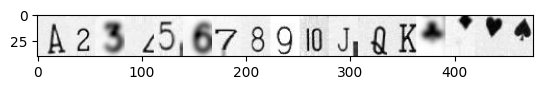

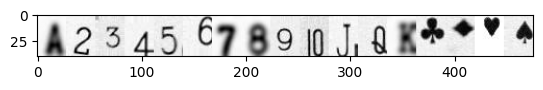

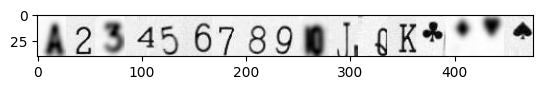

In [ ]:
for i in range(3):
    image_list = [] # init the image list for visualization
    for label in df['label'].unique(): 
        row = df[df['label'] == label].iloc[i]

        image = row.drop('label').values.reshape(40, 28)
        image_list.append(image)

    image_stack = np.hstack(image_list)
    plt.imshow(image_stack, cmap = 'gray')
    plt.show()

In [ ]:
def load_data(is_test = False):
    
    df = pd.read_csv(file_path)

    # divide the df into X and y then convert to numpy array
    y = df['label']
    y = y - 1 # change the 1-17 labels to 0-16 intead for the keras / TF process and to mitigate indexing errors
    X = df.drop(columns = 'label')

    y = y.to_numpy()
    X = X.to_numpy()

    labels = y.astype(np.uint8)
    images = X.astype(np.uint8)

    # Let's start by fixing the sizes, channels last and normalizing
    images = images/255.0
    images = np.expand_dims(images.reshape((-1,40,28)), axis=3)
    # the image data has been resized to (samples,image_rows,image_cols,image_channels)

    # and one hot encoding the output values
    NUM_CLASSES = len(np.unique(y))
    labels = keras.utils.to_categorical(labels, NUM_CLASSES)
    
    # create a dataset 
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if not is_test:
        # only shuffle the training set
        dataset = dataset.shuffle(1024) # buffer size for shuffeling data
    dataset = dataset.batch(128)
    
    return dataset

ds_train = load_data()
ds_test = load_data(is_test=True)

Here we establish the create_cnn_model function

In [ ]:
%%time

def create_cnn_model(model_name, input_shape = [40,28,1], kernel_size= (3,3), pool_size=(2,2), 
                     filters_per_conv_layer = [32], # number of filters to use and how many convolutional layers to use 
                     dense_layer_sizes = [NUM_CLASSES], # number of neurons in each layer after flattening
                     use_dropout=False
                    ):
    
    cnn  = Sequential(name=model_name)
    cnn.add( Input(input_shape) )
    
    # convolutional layers
    for num_filters in filters_per_conv_layer:
        cnn.add( Conv2D(filters=num_filters, 
                        kernel_size=kernel_size, 
                        padding='same',
                        activation='relu',
                         ) )
        
        cnn.add( MaxPooling2D(pool_size=pool_size) )

    cnn.add( Flatten() )
    if len(dense_layer_sizes) > 1:
        # if layers preceding the final number of classes, make relu
        for num_hidden in dense_layer_sizes[:-2]:
            cnn.add( Dense(num_hidden, activation='relu') )
            # optionally use Dropout
            if use_dropout: cnn.add( Dropout(0.5) )
    # final layer for classes
    cnn.add( Dense(dense_layer_sizes[-1], activation='softmax') )

    return cnn


CPU times: user 11 µs, sys: 0 ns, total: 11 µs
Wall time: 15.3 µs


Here we establish the compare_models function

In [ ]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

def compare_models(models, ds_test, fig_size=(15,5), labels='auto'):
    ''' Plot confusion matrices for each model, with names
    '''
    plt.figure(figsize=fig_size)
    
    y_test = []
    for _, label_tensor in ds_test:
        # Convert the label tensor to a NumPy array and append it to the list
        y_test.append(label_tensor.numpy())
    y_test = np.argmax(np.vstack(y_test),axis=1) # stack into single array, get integer class

    # plot confusion matrices 
    num_plots = len(models)
    i = 1
    for model in models:
        yhat = np.argmax(model.predict(ds_test), axis=1)
        acc = mt.accuracy_score(y_test,yhat)

        cm = mt.confusion_matrix(y_test,yhat)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        
        plt.subplot(1,num_plots,i)
        
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels, yticklabels=labels)
        plt.title(f'{model.name}: {acc:.4f}')
        i += 1
    

For the different CNN architecture, I will try models with the following parameters

Model 1 (CNN1)
Kernel size: 
Pooling size: 
Num of layers:
Filters per layer: 
Dropout?: 

Model 2 (CNN2)
Kernel size: 
Pooling size: 
Num of layers:
Filters per layer: 
Dropout?: 

The reason I choose to do it this way.....

In [ ]:
%%time

# changes: 
#    1. Baseline: 2 conv layers and two output layers
cnn1 = create_cnn_model(
    model_name  = 'PokerConvSmall',
    input_shape = [40,28,1],
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,32], 
    dense_layer_sizes      = [50,NUM_CLASSES], 
    use_dropout = False
)

cnn2 = create_cnn_model(
    model_name  = 'PokerConvLarge',
    input_shape = [40,28,1],
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,64], 
    dense_layer_sizes      = [256,50,NUM_CLASSES], 
    use_dropout = True
)

cnn3 = create_cnn_model(
    model_name  = 'Name TBD.....',
    input_shape = [40,28,1],
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,64], 
    dense_layer_sizes      = [256,50,NUM_CLASSES], 
    use_dropout = True
)

cnn4 = create_cnn_model(
    model_name  = 'Name TBD.....',
    input_shape = [40,28,1],
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,64], 
    dense_layer_sizes      = [256,50,NUM_CLASSES], 
    use_dropout = True
)

for model in [cnn1]:
    # Let's train the model 
    model.compile(loss='mean_squared_error',
                  optimizer='rmsprop',
                  metrics=['accuracy'])
    
    print(model.summary())
    
    # we need to exapnd the dimensions here to give the 
    #   "channels" dimension expected by Keras
    history = model.fit(ds_train, 
            batch_size=32, epochs=15, 
            shuffle=True, verbose=1,
            validation_data=ds_test)



Model: "PokerConvSmall"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 40, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 20, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 20, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 10, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 2240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 17)             │        38,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,665 (186.19 KB)

 Trainable params: 47,665 (186.19 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step - accuracy: 0.2342 - loss: 0.0512 - val_accuracy: 0.0977 - val_loss: 0.0646
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.2947 - loss: 0.0495 - val_accuracy: 0.0613 - val_loss: 0.0734
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.4560 - loss: 0.0422 - val_accuracy: 0.3091 - val_loss: 0.0522
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - accuracy: 0.7297 - loss: 0.0237 - val_accuracy: 0.5624 - val_loss: 0.0339
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.8706 - loss: 0.0115 - val_accuracy: 0.7680 - val_loss: 0.0206
Epoch 6/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step - accuracy: 0.8936 - loss: 0.0094 - val_accuracy: 0.7562 - val_loss: 0.0196
Epoch 7/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.8983 - loss: 0.0087 - val_accuracy: 0.7657 - val_loss: 0.0190
Epoch 8/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.9079 - loss: 0.0080 - val

In [ ]:
labels = [
    "Ace",
    "Two",
    "Three",
    "Four",
    "Five",
    "Six",
    "Seven",
    "Eight",
    "Nine",
    "Ten",
    "Jack",
    "Queen",
    "King",
    "Clubs",
    "Diamonds",
    "Hearts",
    "Spades"
]

70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


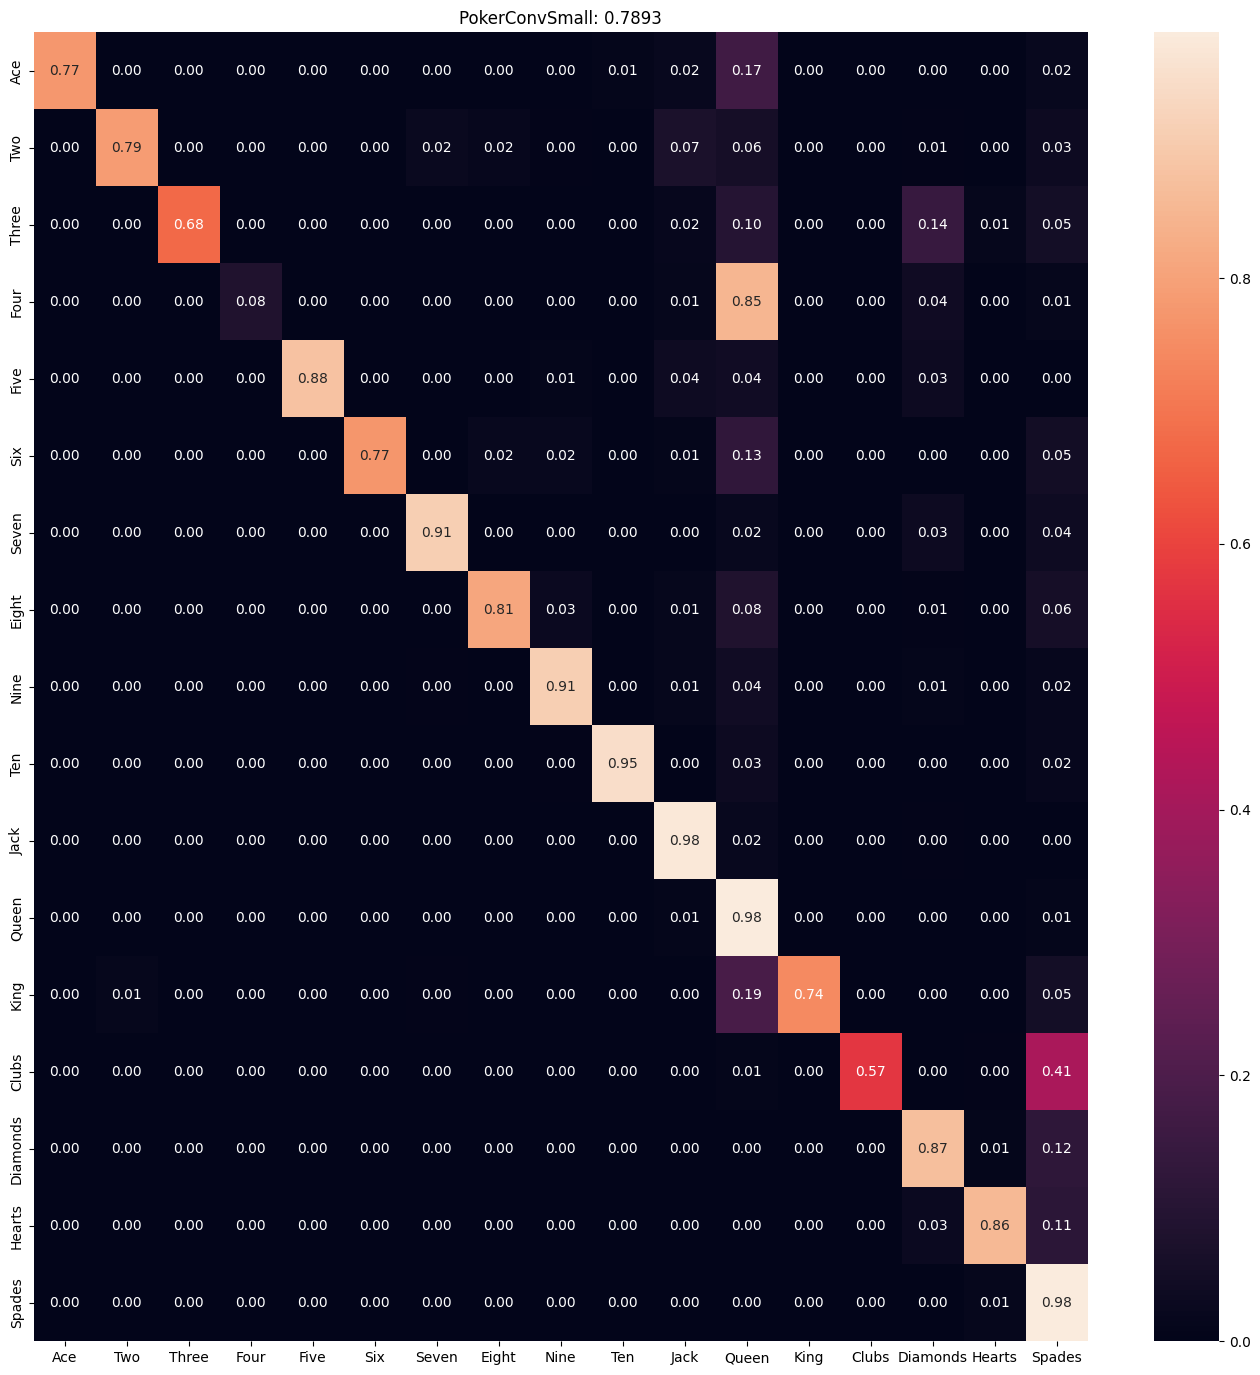

In [ ]:
compare_models([cnn1], ds_test, fig_size=(17, 17), labels=labels)
#compare_models([cnn2], ds_test, fig_size=(17, 17), labels=labels)
#compare_models([cnn3], ds_test, fig_size=(17, 17), labels=labels)
#compare_models([cnn3], ds_test, fig_size=(17, 17), labels=labels)

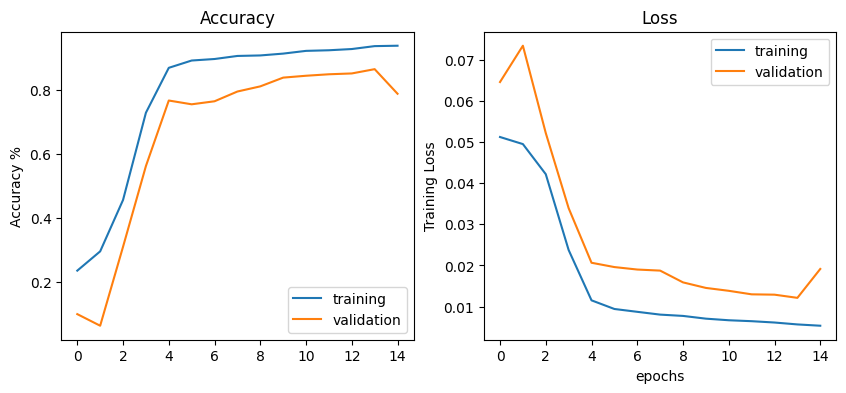

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='training')

plt.ylabel('Accuracy %')
plt.title('Training')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='training')
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('epochs')
plt.title('Loss')
plt.legend()
plt.show()

## Exceptional Work: Transfer Learning with Pretrained Weights

For the exceptional work section, we implemented transfer learning using a pretrained CNN backbone. Transfer learning is appropriate here because pretrained convolutional layers already capture reusable visual features such as edges, textures, shapes, and object-level patterns. This is useful for image classification because our model can start from learned image representations instead of learning every visual feature from scratch.

We compare this transfer learning model against the best CNN model developed above using the same train/test split and evaluation metrics. This keeps the comparison fair and allows us to evaluate whether pretrained image features improve classification performance.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Resizing(224, 224),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(transfer_history.history['accuracy'], label='Training Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(transfer_history.history['loss'], label='Training Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Transfer Learning Interpretation

The transfer learning model should be compared directly against the best custom CNN from the previous section. If the validation performance is higher or more stable, this suggests that pretrained visual features helped the model generalize better. If the performance is similar or lower, then the custom CNN may already be sufficient for this dataset, or the dataset may differ enough from ImageNet that pretrained features provide less benefit.

Overall, this section extends the original CNN modeling by testing whether pretrained convolutional features improve classification performance under the same evaluation setup.
